In [8]:
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [9]:
load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [10]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [11]:
def gen_outline(state: BlogState) -> BlogState:

    title = state['title']

    prompt = f'gnerate a detailed outline for blog on the given topic-{title}' 

    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

In [12]:
def gen_blog(state: BlogState) -> BlogState:
    
    title = state['title']
    outline = state['outline']

    prompt = f'write a detailed blog on the title-{title} using the following outlines \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [13]:
graph = StateGraph(BlogState)

graph.add_node('gen_outline', gen_outline)
graph.add_node('gen_blog', gen_blog)

graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline', 'gen_blog')
graph.add_edge('gen_blog', END)

workflow = graph.compile()

In [14]:
initial_state = {'title': 'Rise of dolar in India'}

final_state = workflow.invoke(initial_state)

print(final_state['content'])

## The Dollar's Ascent: Decoding its Rise and Impact on India

Ever noticed the news headlines about the Indian Rupee hitting new lows against the US Dollar? It's not just a number on a screen; it's a trend with significant implications for every Indian, from the price of your petrol to the cost of your child's overseas education. The "rise of the dollar" essentially means that the US Dollar is strengthening, and consequently, the Indian Rupee is weakening or depreciating against it. This shift isn't merely an abstract economic phenomenon; it's a powerful force that touches daily life, influences business decisions, and shapes the overall economic landscape of our nation.

This blog post will delve into the key factors driving the dollar's strength, explore its multifaceted impacts on India, and discuss what the future might hold for the Rupee-Dollar dynamic.

### Understanding the Basics: The Rupee-Dollar Exchange Rate

Before we dive into the complexities, let's clarify the fundament

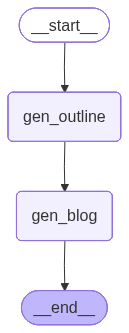

In [15]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())